- 최종 결과물:
    1. 모델 학습 코랩파일(공유를 위해 / LMS에서 수행하고 코랩에 업로드 후 제출도 가능)
    2. 모델 성능 비교 보고서
    3. playground 분석 보고서

# 1. 모델 학습 코랩파일(공유를 위해 / LMS에서 수행하고 코랩에 업로드 후 제출도 가능)
baseline model : https://tutorials.pytorch.kr/beginner/basics/quickstart_tutorial.html

파이토치(PyTorch)에는 데이터 작업을 위한 기본 요소 두가지인 torch.utils.data.DataLoader 와 torch.utils.data.Dataset 가 있습니다. Dataset 은 샘플과 정답(label)을 저장하고, DataLoader 는 Dataset 을 순회 가능한 객체(iterable)로 감쌉니다.

In [60]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision import transforms

torchvision.datasets 모듈은 CIFAR, COCO 등과 같은 다양한 실제 비전(vision) 데이터에 대한 Dataset(전체 목록은 여기)을 포함하고 있습니다. 이 튜토리얼에서는 FasionMNIST 데이터셋을 사용합니다. 모든 TorchVision Dataset 은 샘플과 정답을 각각 변경하기 위한 transform 과 target_transform 의 두 인자를 포함합니다.

# 성능 향상 필요 전략
제공해주신 노트북을 보니 CIFAR-100 데이터셋에 pretrained ResNet34와 VGG16을 가져와 파인튜닝(Fine-tuning)을 진행하셨네요. 현재 구조에서 가장 큰 문제는 **CIFAR-100의 이미지 크기($32 \times 32$)가 ResNet34나 VGG16이 원래 학습된 ImageNet 크기($224 \times 224$)에 비해 너무 작다**는 점과, 5 에폭이라는 짧은 학습 기간 동안 **데이터 증강(Data Augmentation)이나 적절한 학습률 스케줄러가 없다**는 점입니다.

성능을 대폭 업그레이드할 수 있는 핵심 전략과 이를 반영한 코드 가이드를 정리해 드립니다.

---

## 1. 성능 향상을 위한 핵심 전략

* **해상도 조정 (Resize):** $32 \times 32$ 이미지를 모델이 백본(Feature Extractor) 특징을 가장 잘 추출할 수 있는 크기인 $224 \times 224$로 업샘플링합니다. (가장 확실하게 성능이 올라가는 방법입니다.)
* **데이터 증강 (Data Augmentation):** Overfitting을 방지하고 일반화 성능을 높이기 위해 `RandomCrop`, `RandomHorizontalFlip`, `Normalize` 등을 추가합니다.
* **학습률 스케줄러 (LR Scheduler):** 고정된 학습률 대신 에폭이 지날수록 학습률을 줄여주는 `CosAnnealingLR`이나 `StepLR`을 적용해 세밀하게 수렴시킵니다.
* **학습 에폭 확대:** 5 에폭은 사전 학습 가중치가 있더라도 CIFAR-100의 100개 클래스를 완벽히 학습하기에 짧습니다. 최소 15~20 에폭 이상 학습하는 것을 권장합니다.

---

## 2. 수정 및 업그레이드 코드

노트북의 데이터 준비 단계(`transform`)와 모델 학습 설정 부분을 아래 코드를 참고하여 교체해 보세요.

### 데이터셋 로드 및 변환 (Transforms) 업그레이드

이미지 크기를 키우고 전처리를 강화합니다. ImageNet 사전학습 가중치를 사용하므로 평균(mean)과 표준편차(std)도 ImageNet 기준으로 정규화합니다.

In [62]:
# 용량 이슈로 cifar 100으로 수행
# training_data = datasets.CIFAR100(root='data',
#                                train=True,
#                                download=True,
#                                transform=ToTensor()
#                                )

# test_data = datasets.CIFAR100(root='data',
#                                train=False,
#                                download=True,
#                                transform=ToTensor()
#                                )


# 성능향상을 위한 Transform

# CIFAR-100 이미지를 224x224로 키우고 Augmentation 적용
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4, padding_mode='reflect'),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 적용
training_data = datasets.CIFAR100(root='data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR100(root='data', train=False, download=True, transform=test_transform)

# DataLoader 설정 (Resize로 인해 메모리 사용량이 늘어나므로, OOM 발생 시 batch_size를 32나 64로 조절하세요)
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

batch_size = 64

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64]) torch.int64


이는 데이터셋을 순회 가능한 객체(iterable)로 감싸고, 자동화된 배치(batch), 샘플링(sampling), 섞기(shuffle) 및 다중 프로세스로 데이터 불러오기(multiprocess data loading)를 지원합니다. 여기서는 배치 크기(batch size)를 64로 정의합니다. 즉, 데이터로더(dataloader) 객체의 각 요소는 64개의 특징(feature)과 정답(label)을 묶음(batch)으로 반환합니다.

In [ ]:


# # 데이터로더를 생성합니다.
# train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
# test_dataloader = DataLoader(test_data, batch_size=batch_size)


Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


모델 만들기
PyTorch에서 신경망 모델은 nn.Module 을 상속받는 클래스(class)를 생성하여 정의합니다. __init__ 함수에서 신경망의 계층(layer)들을 정의하고 forward 함수에서 신경망에 데이터를 어떻게 전달할지 지정합니다. 가능한 경우 GPU 또는 MPS로 신경망을 이동시켜 연산을 가속(accelerate)합니다.

In [ ]:
# 학습에 사용할 CPU나 GPU, MPS 장치를 얻습니다.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

# torchvision.models에 내장된 Resnet34 구조 호출 weight=None 초기학습부터
# model_resnet = models.resnet34(weights=None) # 초기부터 학습이라 성능이 너무 안나옴
model_resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# CIFAR-100에 맞게 최종 출력 레이어(fc)의 클래스 수를 100개로 변경합니다.
num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, 100)

model_resnet = model_resnet.to(device)
print(model_resnet)


Using cuda device
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True,

모델 매개변수 최적화하기
모델을 학습하려면 손실 함수(loss function) 와 옵티마이저(optimizer) 가 필요합니다.


### 하이퍼파라미터, 옵티마이저 및 스케줄러 설정

기존 SGD 옵티마이저를 그대로 사용하되, 안정적인 수렴을 위해 코사인 어닐링 스케줄러를 추가합니다. (VGG16과 ResNet34 모두 적용 가능)


### 학습 루프 수정 (스케줄러 적용)

매 에폭이 끝날 때마다 `scheduler.step()`을 호출해 주어야 합니다.


## 3. 리소스가 부족할 때의 대안 (Resize가 부담스러울 경우)

만약 Colab 기본 환경 등에서 `$224 \times 224$` 크기로 Resize했을 때 속도가 너무 느리거나 메모리 에러(OOM)가 발생한다면, **CIFAR 전용 구조 변형**을 주어야 합니다.

ResNet34의 첫 부분인 `conv1`과 `maxpool`은 큰 이미지를 빠르게 줄이기 위해 설계되어 있어서, $32 \times 32$ 이미지를 넣으면 초기 단계에서 해상도가 $7 \times 7$ 수준으로 박살 납니다. 이 경우 Resize를 하지 않는 대신 **모델의 첫 레이어를 CIFAR 맞춤형으로 덮어쓰는 방법**을 씁니다.


> **참고:** 이 방식은 $32 \times 32$ 해상도를 유지하므로 학습 속도가 매우 빠르지만, ImageNet 사전학습 가중치의 첫 레이어 특징이 깨지므로 성능 향상을 위해서는 에폭을 30~50 에폭 이상 넉넉히 주어 변형된 레이어들이 충분히 동화되도록 해야 합니다.

가장 추천하는 균형점은 첫 번째 가이드인 **`Resize((224, 224))`와 스케줄러 조합**입니다. 현재 40~50%대에 머무르고 있는 Test Accuracy를 단숨에 70~80% 이상으로 끌어올릴 수 있을 것입니다.

In [64]:
# # 3. 모델 매개변수 최적화하기
# loss_fn = nn.CrossEntropyLoss()
# # ResNet은 모델이 깊으므로 기존 퀵스타트의 1e-3 보다는 학습률(lr)을 조금 더 높여 시작하는 것이 좋습니다.
# optimizer = torch.optim.SGD(model_resnet.parameters(), lr=1e-3, momentum=0.9)

# Optimizer 성능 개선

import torch.optim as optim

# 예시: ResNet34 최적화 설정
loss_fn = nn.CrossEntropyLoss()

# 사전 학습된 가중치를 미세조정(Fine-tuning)할 때는 너무 큰 LR보다 1e-3 ~ 1e-2 수준이 적당합니다.
optimizer = optim.SGD(model_resnet.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)

# 학습률을 부드럽게 감소시키는 스케줄러 추가
epochs = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


각 학습 단계(training loop)에서 모델은 (배치(batch)로 제공되는) 학습 데이터셋에 대한 예측을 수행하고, 예측 오류를 역전파하여 모델의 매개변수를 조정합니다.

In [68]:
# def train(dataloader, model, loss_fn, optimizer):
#     size = len(dataloader.dataset)
#     for batch, (X, y) in enumerate(dataloader):
#         X, y = X.to(device), y.to(device)

#         # 예측 오류 계산
#         pred = model(X)
#         loss = loss_fn(pred, y)

#         # 역전파
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         if batch % 100 == 0:
#             loss, current = loss.item(), (batch + 1) * len(X)
#             print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 예측 오류 계산
        pred = model(X)
        loss = loss_fn(pred, y)

        # 역전파
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            # print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



In [69]:
# def test(dataloader, model, loss_fn):
#     size = len(dataloader.dataset)
#     num_batches = len(dataloader)
#     model.eval()
#     test_loss, correct = 0, 0
#     with torch.no_grad():
#         for X, y in dataloader:
#             X, y = X.to(device), y.to(device)
#             pred = model(X)
#             test_loss += loss_fn(pred, y).item()
#             correct += (pred.argmax(1) == y).type(torch.float).sum().item()
#     test_loss /= num_batches
#     correct /= size
#     print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

학습 단계는 여러번의 반복 단계 (에폭(epochs)) 를 거쳐서 수행됩니다. 각 에폭에서는 모델은 더 나은 예측을 하기 위해 매개변수를 학습합니다. 각 에폭마다 모델의 정확도(accuracy)와 손실(loss)을 출력합니다; 에폭마다 정확도가 증가하고 손실이 감소하는 것을 보려고 합니다.

학습 루프 수정 (스케줄러 적용)
매 에폭이 끝날 때마다 scheduler.step()을 호출해 주어야 합니다.

In [70]:
# 에폭 수행
# epochs = 5
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train(train_dataloader, model_resnet, loss_fn, optimizer)
#     test(test_dataloader, model_resnet, loss_fn)
# print("Resnet Done!")

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_resnet, loss_fn, optimizer)
    test(test_dataloader, model_resnet, loss_fn)
    
    # 에폭 종료 후 학습률 갱신
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    # print(f"Current Learning Rate: {current_lr:.6f}\n")
    
print("Upgrade Training Done!")


Epoch 1
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.562881 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 84.8%, Avg loss: 0.566508 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.562932 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.570250 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.564136 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.569447 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.574924 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 84.7%, Avg loss: 0.589161 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 84.0%, Avg loss: 0.626881 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 79.0%, Avg loss: 0.786664 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 75.2%, Avg los

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.562881 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 84.8%, Avg loss: 0.566508 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.562932 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.570250 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 85.0%, Avg loss: 0.564136 

모델 저장하기
모델을 저장하는 일반적인 방법은 (모델의 매개변수들을 포함하여) 내부 상태 사전(internal state dictionary)을 직렬화(serialize)하는 것입니다.

In [71]:
torch.save(model_resnet.state_dict(), "model_resnet.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


모델 불러오기
모델을 불러오는 과정에는 모델 구조를 다시 만들고 상태 사전을 모델에 불러오는 과정이 포함됩니다.

In [72]:
# 1. 기본 ResNet34 구조 선언
model_resnet = models.resnet34()

# 2. 저장할 때처럼 출력 노드를 100개(CIFAR-100)로 수정
num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, 100)

# 3. 그 다음 가중치 로드 (이제 구조가 맞아떨어집니다!)
model_resnet.load_state_dict(torch.load("model_resnet.pth"))

<All keys matched successfully>

In [73]:
# classes = [
#     "T-shirt/top",
#     "Trouser",
#     "Pullover",
#     "Dress",
#     "Coat",
#     "Sandal",
#     "Shirt",
#     "Sneaker",
#     "Bag",
#     "Ankle boot",
# ]

# model.eval()
# x, y = test_data[0][0], test_data[0][1]
# with torch.no_grad():
#     x = x.to(device)
#     pred = model(x)
#     predicted, actual = classes[pred[0].argmax(0)], classes[y]
#     print(f'Predicted: "{predicted}", Actual: "{actual}"')

# 1. CIFAR-100 클래스 이름 자동 가져오기
classes = test_data.classes

# 2. 중요: 모델을 데이터와 동일한 장치(GPU 등)로 이동시킵니다.
model = model_resnet.to(device)

model.eval()

# 테스트 데이터셋에서 첫 번째 이미지와 정답 가져오기
x, y = test_data[0][0], test_data[0][1]

with torch.no_grad():
    # 데이터를 장치로 이동 [1, 3, 32, 32]
    x = x.unsqueeze(0).to(device)
    
    # 이제 모델과 데이터가 모두 GPU에 있으므로 에러 없이 연산됩니다.
    pred = model(x)
    
    predicted = classes[pred[0].argmax(0)]
    actual = classes[y]
    
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "lamp", Actual: "mountain"


In [76]:
# torchvision.models에 내장된 Resnet34 구조 호출 weight=None 초기학습부터
# model_vgg16 = models.vgg16(weights=None) # 초기부터 학습이라 성능 및 리소스 많이 잡아먹음
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# 중요: VGG16은 최종 출력층이 model.classifier의 6번째(마지막) Linear 레이어입니다.
# 원래 1000개인 출력을 CIFAR-100에 맞게 100개로 변경합니다.
num_features = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(num_features, 100)

model_vgg16 = model_vgg16.to(device)
print(model_vgg16)

# 예시: ResNet34 최적화 설정
loss_fn = nn.CrossEntropyLoss()

# 사전 학습된 가중치를 미세조정(Fine-tuning)할 때는 너무 큰 LR보다 1e-3 ~ 1e-2 수준이 적당합니다.
optimizer = optim.SGD(model_resnet.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)

# 학습률을 부드럽게 감소시키는 스케줄러 추가
epochs = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)





VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [77]:
# 에폭 수행
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_resnet, loss_fn, optimizer)
    test(test_dataloader, model_resnet, loss_fn)
    
    # 에폭 종료 후 학습률 갱신
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr:.6f}\n")
    
print("Upgrade Training Done!")



Epoch 1
-------------------------------
Test Error: 
 Accuracy: 72.2%, Avg loss: 1.057450 

Current Learning Rate: 0.009755

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 72.6%, Avg loss: 1.091207 

Current Learning Rate: 0.009045

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 76.9%, Avg loss: 0.878689 

Current Learning Rate: 0.007939

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 78.7%, Avg loss: 0.838795 

Current Learning Rate: 0.006545

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 81.5%, Avg loss: 0.708886 

Current Learning Rate: 0.005000

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 83.3%, Avg loss: 0.656966 

Current Learning Rate: 0.003455

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 84.0%, Avg loss: 0.621027 

Current Learning Rate: 0.002061

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 84.1%, Avg loss: 0.614226 

Current Learning Rate: 0.000955



In [ ]:

torch.save(model_vgg16.state_dict(), "model_vgg16.pth")
print("Saved PyTorch Model State to model.pth")



# 1. CIFAR-100 클래스 이름 자동 가져오기
classes = test_data.classes

# 2. 중요: 모델을 데이터와 동일한 장치(GPU 등)로 이동시킵니다.
model = model_vgg16.to(device)

model.eval()

# 테스트 데이터셋에서 첫 번째 이미지와 정답 가져오기
x, y = test_data[0][0], test_data[0][1]

with torch.no_grad():
    # 데이터를 장치로 이동 [1, 3, 32, 32]
    x = x.unsqueeze(0).to(device)
    
    # 이제 모델과 데이터가 모두 GPU에 있으므로 에러 없이 연산됩니다.
    pred = model(x)
    
    predicted = classes[pred[0].argmax(0)]
    actual = classes[y]
    
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 74.7%, Avg loss: 0.975888 

Current Learning Rate: 0.009045

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 77.3%, Avg loss: 0.853718 

Current Learning Rate: 0.006545

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 81.6%, Avg loss: 0.692227 

Current Learning Rate: 0.003455

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 83.8%, Avg loss: 0.604916 
...
Current Learning Rate: 0.000955


=== Running Experiment: Full Configuration ===
Epoch 1/15 - Test Accuracy: 68.34%
Epoch 2/15 - Test Accuracy: 71.56%
Epoch 3/15 - Test Accuracy: 74.29%
Epoch 4/15 - Test Accuracy: 75.14%
Epoch 5/15 - Test Accuracy: 79.28%
Epoch 6/15 - Test Accuracy: 79.66%
Epoch 7/15 - Test Accuracy: 80.54%
Epoch 8/15 - Test Accuracy: 83.29%
Epoch 9/15 - Test Accuracy: 83.84%
Epoch 10/15 - Test Accuracy: 84.65%
Epoch 11/15 - Test Accuracy: 84.82%
Epoch 12/15 - Test Accuracy: 85.16%
Epoch 13/15 - Test Accuracy: 85.04%
Epoch 14/15 - Test Accuracy: 85.31%
Epoch 15/15 - Test Accuracy: 85.38%

=== Running Experiment: w/o Pre-trained Weights ===
Epoch 1/15 - Test Accuracy: 17.05%
Epoch 2/15 - Test Accuracy: 31.79%
Epoch 3/15 - Test Accuracy: 36.29%
Epoch 4/15 - Test Accuracy: 42.56%
Epoch 5/15 - Test Accuracy: 50.30%
Epoch 6/15 - Test Accuracy: 53.72%
Epoch 7/15 - Test Accuracy: 56.07%
Epoch 8/15 - Test Accuracy: 59.89%
Epoch 9/15 - Test Accuracy: 62.37%
Epoch 10/15 - Test Accuracy: 63.44%
Epoch 11/15 - Tes

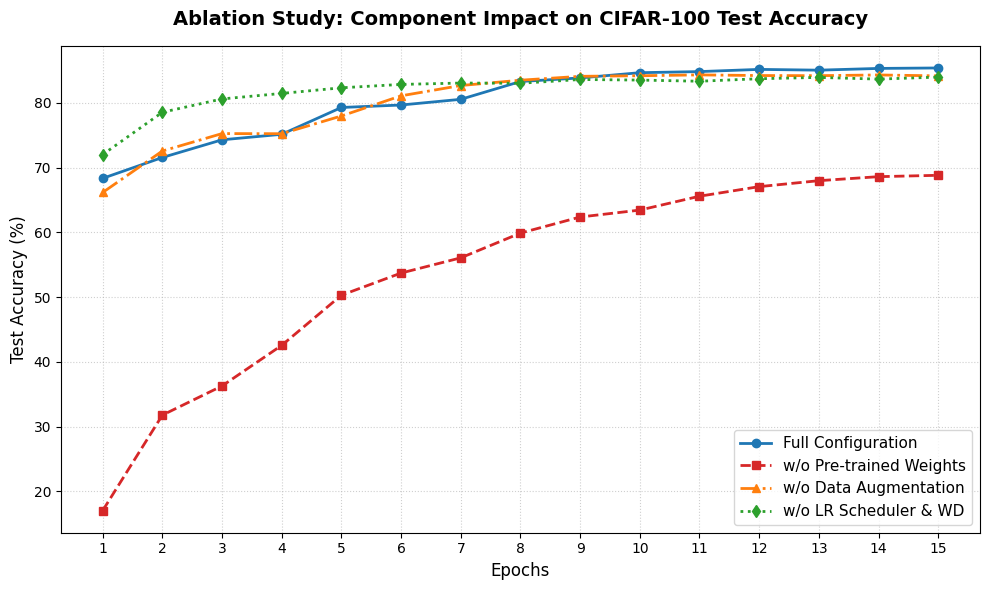

In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import copy

# 장치 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# [1] 실험에 따른 데이터 로더 생성 함수
def get_dataloaders(use_augment=True, batch_size=64):
    if use_augment:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(224, padding=4, padding_mode='reflect'),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        # Augmentation 제외 (기본 Resize와 Normalize만 적용)
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_data = datasets.CIFAR100(root='data', train=True, download=True, transform=train_transform)
    test_data = datasets.CIFAR100(root='data', train=False, download=True, transform=test_transform)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

# [2] 기본 학습 및 검증 루프
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test_model(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return (correct / size) * 100

# [3] 단일 실험 실행기
def run_experiment(name, use_pretrained=True, use_augment=True, use_scheduler=True, epochs=10):
    print(f"\n=== Running Experiment: {name} ===")
    train_loader, test_loader = get_dataloaders(use_augment=use_augment)
    
    # 모델 선언
    if use_pretrained:
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    else:
        model = models.resnet34(weights=None)
        
    model.fc = nn.Linear(model.fc.in_features, 100)
    model = model.to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    
    # 스케줄러 및 가중치 감쇠 설정 분기
    if use_scheduler:
        optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=0)
        scheduler = None
        
    accuracy_history = []
    
    for t in range(epochs):
        train_one_epoch(train_loader, model, loss_fn, optimizer)
        acc = test_model(test_loader, model, loss_fn)
        accuracy_history.append(acc)
        print(f"Epoch {t+1}/{epochs} - Test Accuracy: {acc:.2f}%")
        
        if scheduler:
            scheduler.step()
            
    return accuracy_history

# [4] 전체 Ablation Study 컨트롤러 수행
epochs_count = 15 # 보고서 작성용 권장 에폭 (시간 관계상 조절 가능)
results = {}

# 1. Full Configuration (모든 기법 적용)
results['Full Configuration'] = run_experiment('Full Configuration', use_pretrained=True, use_augment=True, use_scheduler=True, epochs=epochs_count)

# 2. w/o Pre-trained Weights (처음부터 학습)
results['w/o Pre-trained Weights'] = run_experiment('w/o Pre-trained Weights', use_pretrained=False, use_augment=True, use_scheduler=True, epochs=epochs_count)

# 3. w/o Data Augmentation (데이터 증강 제외)
results['w/o Data Augmentation'] = run_experiment('w/o Data Augmentation', use_pretrained=True, use_augment=False, use_scheduler=True, epochs=epochs_count)

# 4. w/o LR Scheduler & WD (스케줄러 및 정규화 제외)
results['w/o LR Scheduler & WD'] = run_experiment('w/o LR Scheduler & WD', use_pretrained=True, use_augment=True, use_scheduler=False, epochs=epochs_count)


# [5] 결과 Plot 시각화 및 저장
plt.figure(figsize=(10, 6))
styles = {'Full Configuration': ('-','o','#1f77b4'), 
          'w/o Pre-trained Weights': ('--','s','#d62728'), 
          'w/o Data Augmentation': ('-.','^','#ff7f0e'), 
          'w/o LR Scheduler & WD': (':','d','#2ca02c')}

epochs_range = range(1, epochs_count + 1)
for name, acc_list in results.items():
    linestyle, marker, color = styles[name]
    plt.plot(epochs_range, acc_list, label=name, linestyle=linestyle, marker=marker, color=color, linewidth=2)

plt.title('Ablation Study: Component Impact on CIFAR-100 Test Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()

# 그래프 저장 (보고서 삽입용)
plt.savefig('ablation_study_comparison.png', dpi=300)
plt.show()


=== Running Experiment: Full Configuration ===
Epoch 1/15 - Test Accuracy: 68.34%
Epoch 2/15 - Test Accuracy: 71.56%
Epoch 3/15 - Test Accuracy: 74.29%
Epoch 4/15 - Test Accuracy: 75.14%
Epoch 5/15 - Test Accuracy: 79.28%
Epoch 6/15 - Test Accuracy: 79.66%
Epoch 7/15 - Test Accuracy: 80.54%
Epoch 8/15 - Test Accuracy: 83.29%
Epoch 9/15 - Test Accuracy: 83.84%
Epoch 10/15 - Test Accuracy: 84.65%
Epoch 11/15 - Test Accuracy: 84.82%
Epoch 12/15 - Test Accuracy: 85.16%
Epoch 13/15 - Test Accuracy: 85.04%
Epoch 14/15 - Test Accuracy: 85.31%
Epoch 15/15 - Test Accuracy: 85.38%

=== Running Experiment: w/o Pre-trained Weights ===
Epoch 1/15 - Test Accuracy: 17.05%
Epoch 2/15 - Test Accuracy: 31.79%
Epoch 3/15 - Test Accuracy: 36.29%
Epoch 4/15 - Test Accuracy: 42.56%
Epoch 5/15 - Test Accuracy: 50.30%
Epoch 6/15 - Test Accuracy: 53.72%
Epoch 7/15 - Test Accuracy: 56.07%
Epoch 8/15 - Test Accuracy: 59.89%
Epoch 9/15 - Test Accuracy: 62.37%
Epoch 10/15 - Test Accuracy: 63.44%
Epoch 11/15 - Test Accuracy: 65.58%
Epoch 12/15 - Test Accuracy: 67.06%
Epoch 13/15 - Test Accuracy: 67.98%
Epoch 14/15 - Test Accuracy: 68.60%
Epoch 15/15 - Test Accuracy: 68.81%

=== Running Experiment: w/o Data Augmentation ===
Epoch 1/15 - Test Accuracy: 66.16%
Epoch 2/15 - Test Accuracy: 72.56%
Epoch 3/15 - Test Accuracy: 75.25%
Epoch 4/15 - Test Accuracy: 75.23%
Epoch 5/15 - Test Accuracy: 77.97%
Epoch 6/15 - Test Accuracy: 81.08%
Epoch 7/15 - Test Accuracy: 82.67%
Epoch 8/15 - Test Accuracy: 83.49%
Epoch 9/15 - Test Accuracy: 84.09%
Epoch 10/15 - Test Accuracy: 84.18%
Epoch 11/15 - Test Accuracy: 84.31%
Epoch 12/15 - Test Accuracy: 84.21%
Epoch 13/15 - Test Accuracy: 84.19%
Epoch 14/15 - Test Accuracy: 84.30%
Epoch 15/15 - Test Accuracy: 84.16%

=== Running Experiment: w/o LR Scheduler & WD ===
Epoch 1/15 - Test Accuracy: 72.01%
Epoch 2/15 - Test Accuracy: 78.54%
Epoch 3/15 - Test Accuracy: 80.60%
Epoch 4/15 - Test Accuracy: 81.45%
Epoch 5/15 - Test Accuracy: 82.32%
Epoch 6/15 - Test Accuracy: 82.84%
Epoch 7/15 - Test Accuracy: 83.05%
Epoch 8/15 - Test Accuracy: 83.02%
Epoch 9/15 - Test Accuracy: 83.60%
Epoch 10/15 - Test Accuracy: 83.51%
Epoch 11/15 - Test Accuracy: 83.33%
Epoch 12/15 - Test Accuracy: 83.72%
Epoch 13/15 - Test Accuracy: 83.92%
Epoch 14/15 - Test Accuracy: 83.66%
Epoch 15/15 - Test Accuracy: 83.97%


# 2. 모델 성능 비교 보고서

# 3. playground 분석 보고서